# 04 — Concurrency scaling of online serving

**Objective.** Measure how aggregate throughput changes as the number of concurrent requests grows — the
primary criterion for the thesis, whose experiments are concurrent online serving.

**Research question.** Which backend turns additional concurrent requests into additional aggregate throughput,
how far does it scale, and where does each backend saturate?

**Data.** `online_points`, campaign `online/main`: closed-loop serving at C = 1, 2, 4, … (sweep rule in notebook
01), five workload shapes on Llama-3.1-8B and three on Llama-3.2-1B, 3 repetitions per point.

**Method.**
- Throughput is measured in the steady-state window with exactly C requests in flight.
- *Speedup* = throughput(C) ÷ throughput(1) of the same configuration; *scaling efficiency* = speedup ÷ C.
- *Knee* = smallest C reaching 90% of the configuration's peak throughput.
- Backend ratios are formed only within the same precision (`comparisons.backend_ratio`), i.e. vLLM BF16 ÷
  llama.cpp BF16. In a closed loop with fixed ISL/OSL, total and output tokens/s differ by the constant
  (ISL+OSL)/OSL, so ratios are the same for both.

**Assumptions.** A configuration's sweep ends by the declared rule (plateau, maximum C or time budget); points
beyond the end are not extrapolated.

In [1]:
import pandas as pd
from IPython.display import display

from llm_backend_analysis.analysis import comparisons, memory, metrics
from llm_backend_analysis.data import loaders, registry
from llm_backend_analysis.reporting import Claim, claims_table, num, pct, rng, show, table, x
from llm_backend_analysis.visualization import plots, theme
from llm_backend_analysis.visualization.export import export_figure

theme.setup_notebook()
NOTEBOOK = "04_concurrency_scaling.ipynb"
MODEL = registry.primary_model()  # Llama-3.1-8B-Instruct; the 1B model is the cross-check

In [2]:
pts = metrics.add_scaling_metrics(loaders.online_points())
primary = pts[pts["model"] == MODEL]
summary = metrics.curve_summary(pts)
sweeps = loaders.online_sweeps()

## 1. Aggregate throughput vs concurrency

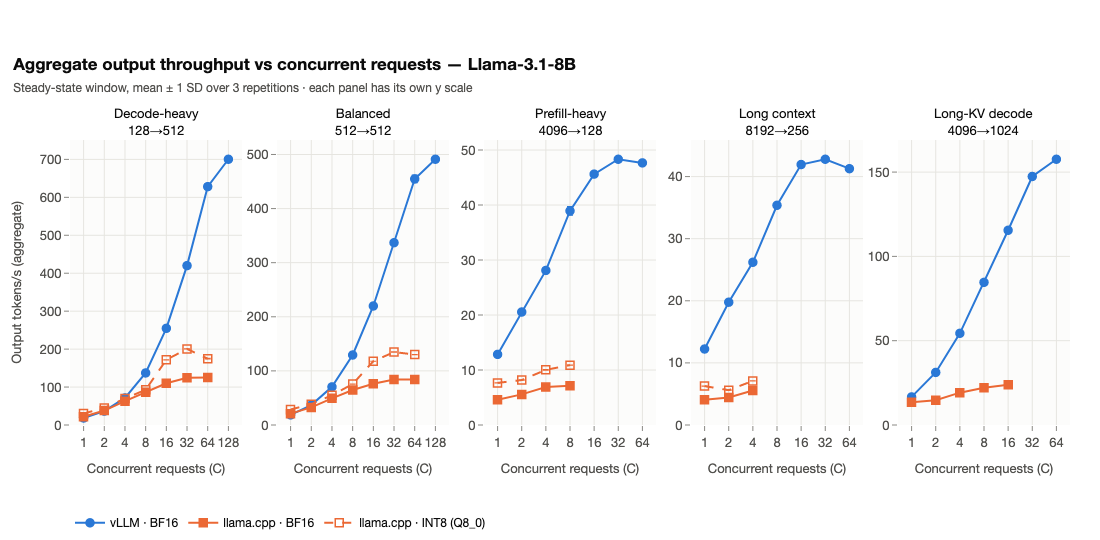

In [3]:
fig = plots.concurrency_lines(
    primary, plots.Panel("output_tok_s_mean", "Output tokens/s (aggregate)", "tok/s"),
    title=f"Aggregate output throughput vs concurrent requests — {registry.model_label(MODEL)}",
    subtitle="Steady-state window, mean ± 1 SD over 3 repetitions · each panel has its own y scale")
fig.show()
export_figure(fig, "throughput_vs_concurrency", source=NOTEBOOK,
              caption="Aggregate output tokens/s vs concurrent requests per workload (8B); vLLM keeps scaling, llama.cpp flattens early.")

In [4]:
s = summary[summary["model"] == MODEL].merge(
    sweeps[["model", "configuration_id", "workload", "last_status", "last_concurrency"]],
    on=["model", "configuration_id", "workload"], how="left")
display(table(s[["workload_shape", "configuration_label", "c1_total_tok_s", "peak_total_tok_s", "peak_concurrency",
                 "peak_over_c1", "knee_concurrency", "max_concurrency", "last_doubling_gain", "last_status"]]
              .rename(columns={"workload_shape": "Workload", "configuration_label": "Configuration",
                               "c1_total_tok_s": "Total tok/s at C=1", "peak_total_tok_s": "Peak total tok/s",
                               "peak_concurrency": "at C", "peak_over_c1": "Peak ÷ C=1", "knee_concurrency": "Knee C (90% of peak)",
                               "max_concurrency": "Highest C run", "last_doubling_gain": "Last doubling",
                               "last_status": "Last sweep point"}),
              {"Total tok/s at C=1": "{:.1f}", "Peak total tok/s": "{:,.0f}", "Peak ÷ C=1": "{:.1f}×",
               "Last doubling": "{:+.0%}"}))

Workload,Configuration,Total tok/s at C=1,Peak total tok/s,at C,Peak ÷ C=1,Knee C (90% of peak),Highest C run,Last doubling,Last sweep point
128→512,vLLM · BF16,23.1,849,128,36.7×,64,128,+9%,ok
128→512,llama.cpp · BF16,27.0,156,32,5.8×,32,64,-2%,ok
128→512,llama.cpp · INT8 (Q8_0),37.7,251,32,6.6×,32,64,-14%,ok
512→512,vLLM · BF16,37.3,857,128,22.9×,64,128,+2%,ok
512→512,llama.cpp · BF16,41.9,158,32,3.8×,16,64,-1%,ok
512→512,llama.cpp · INT8 (Q8_0),57.5,257,32,4.5×,32,64,-3%,ok
4096→128,vLLM · BF16,423.7,"1,175",64,2.8×,16,64,+2%,ok
4096→128,llama.cpp · BF16,151.4,176,4,1.2×,2,8,-0%,ok
4096→128,llama.cpp · INT8 (Q8_0),252.7,277,4,1.1×,1,8,-3%,ok
8192→256,vLLM · BF16,403.8,"1,013",64,2.5×,8,64,+0%,ok


In [5]:
sv = s[s["backend"] == "vllm"]
sl = s[(s["backend"] == "llama_cpp") & (s["precision"] == "bf16")]
show(f"**vLLM BF16** reaches {rng(sv['peak_total_tok_s'])} total tok/s, {rng(sv['peak_over_c1'], x)} its own C=1 throughput, "
     f"with knees at C = {rng(sv['knee_concurrency'])}. **llama.cpp BF16** peaks at {rng(sl['peak_total_tok_s'])} tok/s, "
     f"{rng(sl['peak_over_c1'], x)} its C=1, with knees at C = {rng(sl['knee_concurrency'])}. "
     f"On the short-prompt shapes (ISL ≤ OSL) the scaling factor is {rng(sv.query('osl >= isl')['peak_over_c1'], x)} (vLLM) vs "
     f"{rng(sl.query('osl >= isl')['peak_over_c1'], x)} (llama.cpp); on the long-prompt shapes {rng(sv.query('osl < isl')['peak_over_c1'], x)} vs "
     f"{rng(sl.query('osl < isl')['peak_over_c1'], x)}.")

**vLLM BF16** reaches 631–1,175 total tok/s, 2.5×–36.7× its own C=1 throughput, with knees at C = 8–64. **llama.cpp BF16** peaks at 117–176 tok/s, 1.1×–5.8× its C=1, with knees at C = 1–32. On the short-prompt shapes (ISL ≤ OSL) the scaling factor is 22.9×–36.7× (vLLM) vs 3.8×–5.8× (llama.cpp); on the long-prompt shapes 2.5×–7.6× vs 1.1×–1.7×.

**Interpretation.** vLLM's throughput keeps rising over one to two orders of magnitude of concurrency; llama.cpp's
rises over the first few doublings and then flattens, very early on long prompts. The difference in *shape*
matters more for the thesis than the difference in level: in vLLM the concurrency axis remains an experimental
variable over C = 1…64/128, whereas in llama.cpp most of that range would produce the same throughput.

## 2. Scaling efficiency and gain per doubling

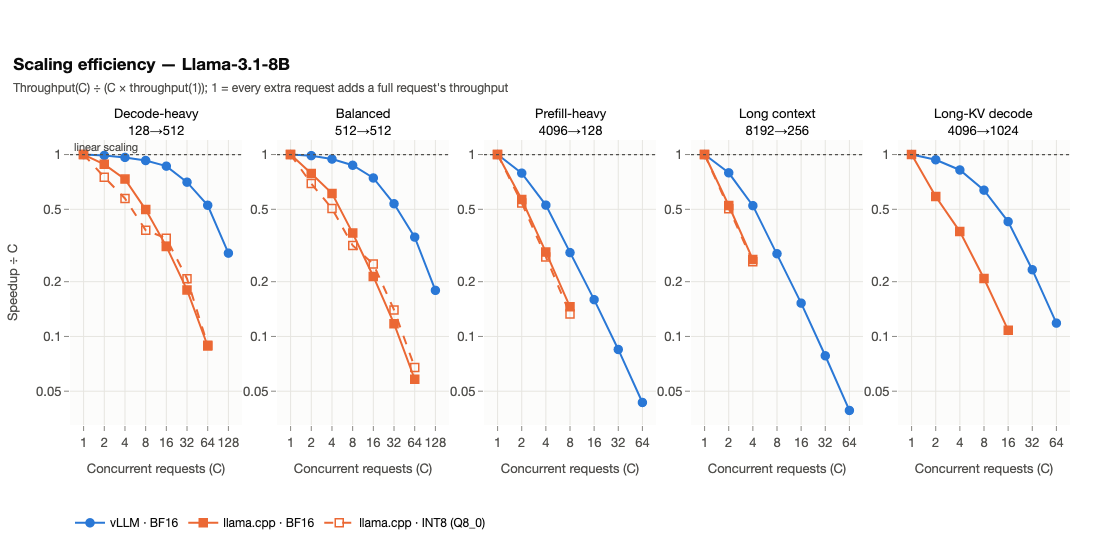

In [6]:
fig = plots.concurrency_lines(
    primary, plots.Panel("scaling_efficiency", "Speedup ÷ C", error=None, log_y=True, share_y=True, fmt=".2f",
                         reference=(1.0, "linear scaling")),
    title=f"Scaling efficiency — {registry.model_label(MODEL)}",
    subtitle="Throughput(C) ÷ (C × throughput(1)); 1 = every extra request adds a full request's throughput")
fig.show()

In [7]:
gains = primary[primary["precision"] == "bf16"].pivot_table(index=["workload_shape", "configuration_label"],
                                                            columns="concurrency", values="gain_vs_prev", sort=False)
gains = gains.drop(columns=[1], errors="ignore")
gains.columns = [f"→ C={c}" for c in gains.columns]
display(table(gains.reset_index().rename(columns={"workload_shape": "Workload", "configuration_label": "Configuration"}),
              {c: "{:+.0%}" for c in gains.columns}, caption="Throughput gain of each doubling of C (BF16 pair)"))

Workload,Configuration,→ C=2,→ C=4,→ C=8,→ C=16,→ C=32,→ C=64,→ C=128
128→512,vLLM · BF16,+98%,+95%,+92%,+86%,+63%,+49%,+9%
128→512,llama.cpp · BF16,+77%,+66%,+36%,+26%,+15%,-2%,–
512→512,vLLM · BF16,+97%,+92%,+85%,+70%,+44%,+31%,+2%
512→512,llama.cpp · BF16,+57%,+55%,+21%,+16%,+10%,-1%,–
4096→128,vLLM · BF16,+58%,+33%,+10%,+10%,+6%,+2%,–
4096→128,llama.cpp · BF16,+13%,+3%,-0%,–,–,–,–
8192→256,vLLM · BF16,+59%,+32%,+9%,+7%,+3%,+0%,–
8192→256,llama.cpp · BF16,+5%,+1%,–,–,–,–,–
4096→1024,vLLM · BF16,+87%,+76%,+55%,+34%,+9%,+2%,–
4096→1024,llama.cpp · BF16,+18%,+28%,+10%,+4%,–,–,–


**Interpretation.** For vLLM the early doublings add close to +100% on the short-prompt shapes and the gains stay
positive to the end of every sweep. llama.cpp's gains shrink after the first doublings and fall to about zero at
the end of its sweeps. Efficiency is relative to each
configuration's own C = 1, so it must be read together with absolute throughput (section 1).

## 3. Direct backend comparison (BF16 vs BF16)

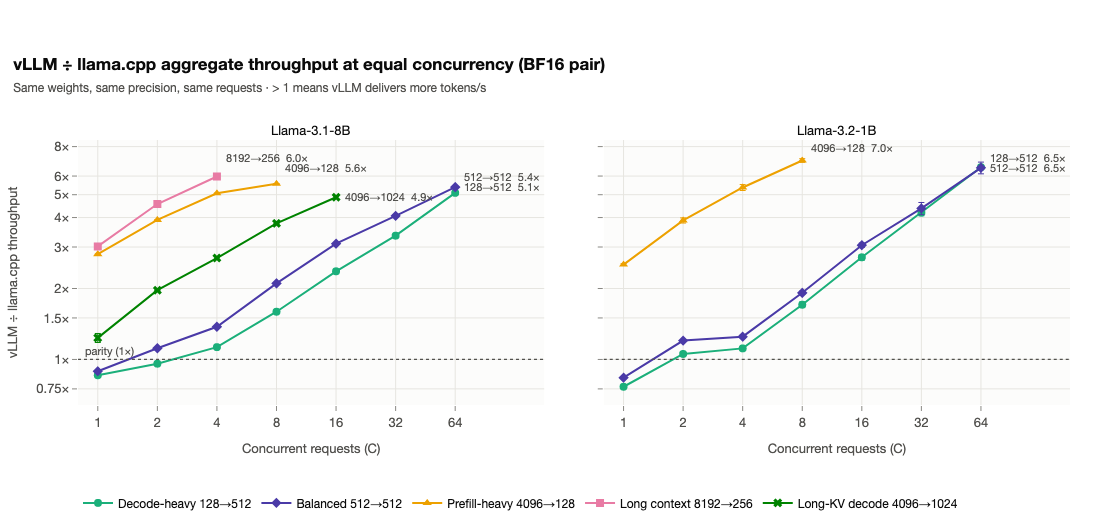

Model,Workload,Ratio at C=1,Highest common C,Ratio there,First C with vLLM ≥ llama.cpp,Monotone from C=2
Llama-3.1-8B,128→512,0.86×,64,5.1×,4,True
Llama-3.1-8B,512→512,0.89×,64,5.4×,2,True
Llama-3.1-8B,4096→128,2.80×,8,5.6×,1,True
Llama-3.1-8B,8192→256,3.02×,4,6.0×,1,True
Llama-3.1-8B,4096→1024,1.23×,16,4.9×,1,True
Llama-3.2-1B,128→512,0.77×,64,6.5×,2,True
Llama-3.2-1B,512→512,0.84×,64,6.5×,2,True
Llama-3.2-1B,4096→128,2.53×,8,7.0×,1,True


In [8]:
ratio = comparisons.backend_ratio(pts, "total_tok_s_mean", precision="bf16")
fig = plots.ratio_vs_concurrency(ratio, title="vLLM ÷ llama.cpp aggregate throughput at equal concurrency (BF16 pair)",
                                 subtitle="Same weights, same precision, same requests · > 1 means vLLM delivers more tokens/s",
                                 y_title="vLLM ÷ llama.cpp throughput")
fig.show()
export_figure(fig, "backend_ratio_vs_concurrency", source=NOTEBOOK,
              caption="vLLM BF16 ÷ llama.cpp BF16 throughput at equal C per workload, 8B and 1B.")
cross = comparisons.crossover_summary(ratio)
display(table(cross.assign(model=cross["model"].map(registry.model_label),
                           workload=cross["workload"].map(lambda w: registry.workload_label(w, short=True)))
              .rename(columns={"model": "Model", "workload": "Workload", "ratio_c1": "Ratio at C=1",
                               "first_c_ratio_ge_1": "First C with vLLM ≥ llama.cpp", "highest_common_c": "Highest common C",
                               "ratio_at_highest_common_c": "Ratio there", "ratio_monotone_from_c2": "Monotone from C=2"})
              .drop(columns=["max_ratio"]), {"Ratio at C=1": "{:.2f}×", "Ratio there": "{:.1f}×"}))

In [9]:
p8 = comparisons.peak_ratio(summary[summary["model"] == MODEL], precision="bf16")
show(f"At C=1 the ratio is {rng(cross['ratio_c1'], x, nd=2)} (llama.cpp ahead where < 1); at the highest common C it is "
     f"{rng(cross['ratio_at_highest_common_c'], x)}. Comparing each backend's *own best* operating point instead of equal C: "
     f"vLLM's peak ÷ llama.cpp's peak = {rng(p8['ratio'], x)} ({registry.model_label(MODEL)}).")

At C=1 the ratio is 0.77×–3.02× (llama.cpp ahead where < 1); at the highest common C it is 4.9×–7.0×. Comparing each backend's *own best* operating point instead of equal C: vLLM's peak ÷ llama.cpp's peak = 5.4×–7.2× (Llama-3.1-8B).

**Interpretation.** The comparison has a crossover. On the short-prompt shapes llama.cpp is ahead at C = 1
(notebook 03); vLLM catches up within the first one or two doublings and its advantage then grows monotonically
with concurrency (table above). On
long-prompt shapes vLLM is ahead from C = 1 because of its faster prefill. Comparing peak against peak (each
backend at its best C) gives a ratio of the same order, so the result does not depend on comparing at an
arbitrary C.

## 4. Is this a property of the backend or of the 8B model?

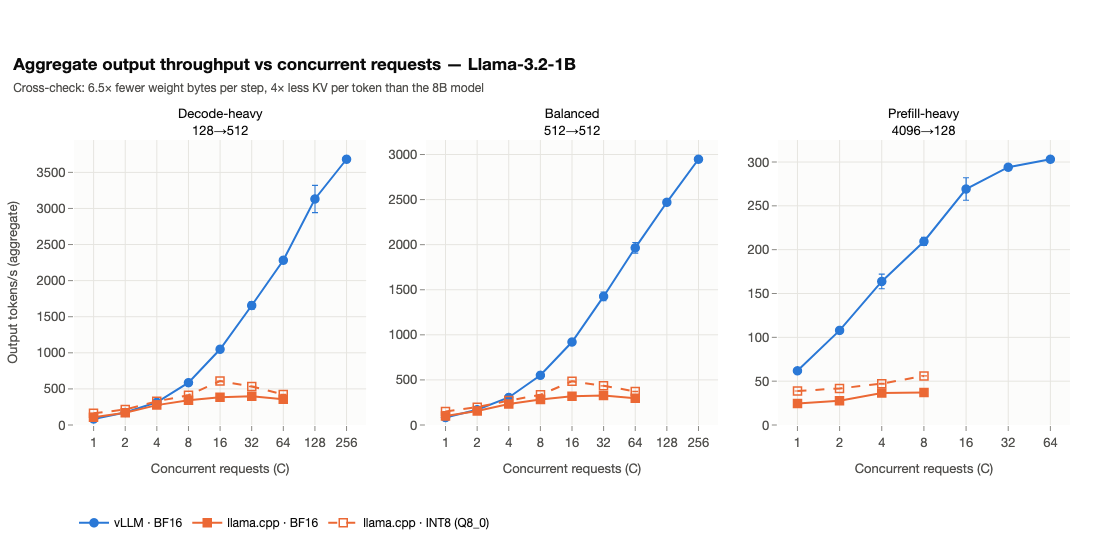

Llama-3.2-1B: peak ÷ C=1 = vLLM · BF16 128→512 42.7× (peak at C=256), llama.cpp · BF16 128→512 3.6× (peak at C=32), vLLM · BF16 512→512 30.7× (peak at C=256), llama.cpp · BF16 512→512 3.2× (peak at C=32), vLLM · BF16 4096→128 3.7× (peak at C=64), llama.cpp · BF16 4096→128 1.2× (peak at C=2).

In [10]:
other = [m for m in pts["model"].unique() if m != MODEL]
for m in other:
    fig = plots.concurrency_lines(
        pts[pts["model"] == m], plots.Panel("output_tok_s_mean", "Output tokens/s (aggregate)", "tok/s"),
        title=f"Aggregate output throughput vs concurrent requests — {registry.model_label(m)}",
        subtitle="Cross-check: 6.5× fewer weight bytes per step, 4× less KV per token than the 8B model")
    fig.show()
    s1 = summary[(summary["model"] == m) & (summary["precision"] == "bf16")]
    show(f"{registry.model_label(m)}: peak ÷ C=1 = "
         + ", ".join(f"{r.configuration_label} {r.workload_shape} {x(r.peak_over_c1)} (peak at C={r.peak_concurrency})"
                     for r in s1.itertuples()) + ".")

The 1B model reproduces the pattern with larger factors: vLLM keeps scaling up to the largest C the sweep rule
allowed, llama.cpp flattens at a similar C as with 8B. The scaling behaviour is therefore a property of the
backends, not of one model size.

## 5. Claims checked against the data

In [11]:
bf16 = summary[summary["precision"] == "bf16"]
v = bf16[bf16["backend"] == "vllm"].set_index(["model", "workload"])
l = bf16[bf16["backend"] == "llama_cpp"].set_index(["model", "workload"])
claims = [
    Claim("vLLM BF16 scales further than llama.cpp BF16 on every model and workload (higher peak ÷ C=1)",
          bool((v["peak_over_c1"] > l["peak_over_c1"]).all()),
          f"vLLM {rng(v['peak_over_c1'], x)} vs llama.cpp {rng(l['peak_over_c1'], x)}"),
    Claim("vLLM BF16 reaches its peak at a higher C than llama.cpp BF16 everywhere",
          bool((v["peak_concurrency"] >= l["peak_concurrency"]).all()),
          f"vLLM C={rng(v['peak_concurrency'])}, llama.cpp C={rng(l['peak_concurrency'])}"),
    Claim("llama.cpp BF16 is ahead at C=1 on the short-prompt shapes (128→512, 512→512)",
          bool((ratio[(ratio["concurrency"] == 1) & ratio["workload"].isin(["decode", "balanced"])]["ratio"] < 1).all()),
          f"ratio at C=1: {rng(ratio[(ratio['concurrency'] == 1) & ratio['workload'].isin(['decode', 'balanced'])]['ratio'], x, nd=2)}"),
    Claim("The vLLM ÷ llama.cpp ratio grows monotonically with C from C=2 on every curve",
          bool(cross["ratio_monotone_from_c2"].all()), f"{int(cross['ratio_monotone_from_c2'].sum())}/{len(cross)} curves"),
    Claim("At the highest common C, vLLM delivers ≥ 4× llama.cpp's throughput on every curve",
          bool((cross["ratio_at_highest_common_c"] >= 4).all()), rng(cross["ratio_at_highest_common_c"], x)),
]
display(claims_table(claims))

Holds,Statement,Evidence (computed)
✓,vLLM BF16 scales further than llama.cpp BF16 on every model and workload (higher peak ÷ C=1),vLLM 2.5×–42.7× vs llama.cpp 1.1×–5.8×
✓,vLLM BF16 reaches its peak at a higher C than llama.cpp BF16 everywhere,"vLLM C=64–256, llama.cpp C=2–32"
✓,"llama.cpp BF16 is ahead at C=1 on the short-prompt shapes (128→512, 512→512)",ratio at C=1: 0.77×–0.89×
✓,The vLLM ÷ llama.cpp ratio grows monotonically with C from C=2 on every curve,8/8 curves
✓,"At the highest common C, vLLM delivers ≥ 4× llama.cpp's throughput on every curve",4.9×–7.0×


## Conclusions

In [12]:
v8, l8 = v.loc[MODEL], l.loc[MODEL]
short_w = [w for w in v8.index if registry.workloads().set_index("workload").loc[w, "osl"] >= registry.workloads().set_index("workload").loc[w, "isl"]]
long_w = [w for w in v8.index if w not in short_w]
show(f"- **Measured:** on {registry.model_label(MODEL)}, vLLM BF16 reaches its peak at C = {rng(v8['peak_concurrency'])} "
     f"({rng(v8['peak_over_c1'], x)} its C=1 throughput); llama.cpp BF16 peaks at C = {rng(l8.loc[short_w, 'peak_concurrency'])} "
     f"on the short-prompt shapes and C = {rng(l8.loc[long_w, 'peak_concurrency'])} on the long-prompt ones "
     f"({rng(l8['peak_over_c1'], x)}). The vLLM ÷ llama.cpp ratio at matched precision goes from {rng(cross['ratio_c1'], x, nd=2)} "
     f"at C = 1 to {rng(cross['ratio_at_highest_common_c'], x)} at the highest common C, on both models.")

- **Measured:** on Llama-3.1-8B, vLLM BF16 reaches its peak at C = 64–128 (2.5×–36.7× its C=1 throughput); llama.cpp BF16 peaks at C = 32 on the short-prompt shapes and C = 4–16 on the long-prompt ones (1.1×–5.8×). The vLLM ÷ llama.cpp ratio at matched precision goes from 0.77×–3.02× at C = 1 to 4.9×–7.0× at the highest common C, on both models.

- **Interpretation:** vLLM converts concurrency into throughput, llama.cpp largely does not beyond small C. The
  mechanism (cost of a batched step, AMX use) is examined in notebook 06.
- **Implication for the thesis:** experiments that vary concurrency to vary load on the memory system need a
  backend whose throughput responds to concurrency over a wide range; only vLLM provides that here.

## Limitations

- Sweeps stop by the declared rule (plateau, extension threshold or time budget), not because of failures; the
  last sweep point of every curve is listed in section 1.
- Equal-C comparisons do not account for latency; notebook 05 adds per-request latency under load.
- llama.cpp INT8 at 4096→1024 was queued when the HBM nodes were drained and is missing.